# Pairwise RMSD analysis between two simulations (V7 & V12) to train classification model

In [4]:
!pip install MDAnalysis

In [5]:
!pip install MDAnalysisTests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 15.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 25.8 MB/s eta 0:00:00
  Created wheel for MDAnalysisTests: filename=mdanalysistests-2.10.0-py3-none-any.whl size=58343066 sha256=eaffead28179338f8be003980f4a26fc65e31f651b4776a128171256a039a112
  Stored in directory: /root/.cache/pip/wheels/48/cc/44/560d1d4b77f1a4b0a8cb5be5d12001c911d7e6190511d7e571
Successfully built MDAnalysisTests


In [6]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD, CRD, DCD2
from MDAnalysis.analysis import diffusionmap, align, rms
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive')

rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)

Mounted at /content/drive


In [9]:
V7 = mda.Universe("./simulations_1HSI_APO_MP/V7/V7.gro", "./simulations_1HSI_APO_MP/V7/md_V7.xtc")
V12 = mda.Universe("./simulations_1HSI_APO_DP/V12/V12.gro", "./simulations_1HSI_APO_DP/V12/md_V12.xtc")

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


In [10]:
aligner = align.AlignTraj(V7,V7, select='name CA',
                        in_memory=True).run()

In [11]:
matrix = diffusionmap.DistanceMatrix(V7, select='name CA').run()

In [12]:
df1 = pd.DataFrame(matrix.results.dist_matrix)

In [40]:
df_a = pd.DataFrame()
df_a

""


In [41]:
prmsd = np.zeros((len(V7.trajectory),
                len(V12.trajectory)))  # x-axis

In [42]:
for i, frame in enumerate(V12.trajectory):
    r = rms.RMSD(V7, V12, select='name CA',
                ref_frame=i).run()
    prmsd[i] = r.results.rmsd[:, -1]

In [43]:
df2 = pd.DataFrame(prmsd)

In [44]:
df_a = pd.concat([df1,df2])

In [45]:
df_a

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
0,0.000000,0.994383,1.040442,1.238331,1.375671,1.612803,1.736932,1.729569,1.662175,1.613887,...,1.846653,1.719511,1.758472,1.890478,2.024987,1.824105,1.614457,2.097221,1.633417,1.607439
1,0.994383,0.000000,1.010989,1.276972,1.316387,1.561848,1.730705,1.692415,1.748262,1.715731,...,1.924368,1.726912,1.767790,1.807619,1.906779,1.788805,1.676042,1.938244,1.572264,1.616234
2,1.040442,1.010989,0.000000,1.180234,1.102326,1.379421,1.625190,1.465464,1.408803,1.339188,...,1.885179,1.640312,1.682914,1.840719,1.897275,1.727949,1.556384,1.971920,1.596366,1.591038
3,1.238331,1.276972,1.180234,0.000000,1.073876,1.143967,1.378054,1.455291,1.633031,1.503859,...,1.913373,1.895395,1.860274,2.199313,2.168885,2.132345,1.921273,2.423260,1.734426,1.888425
4,1.375671,1.316387,1.102326,1.073876,0.000000,1.001159,1.458125,1.172143,1.335414,1.122109,...,1.730447,1.792596,1.786313,2.174086,2.287330,1.970693,1.769534,2.433516,1.828562,1.789331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,1.888115,1.843770,1.816386,1.807659,1.844369,1.985730,2.061419,1.714849,2.023538,1.914431,...,1.629893,1.674991,1.413362,1.740850,1.920717,1.737084,1.621358,1.978946,1.514601,1.573571
997,1.827203,1.696892,1.721528,1.763720,1.816619,1.961040,2.084736,1.848836,2.048876,1.918624,...,1.751125,1.624446,1.475967,1.708086,1.910426,1.728942,1.651876,1.927915,1.522799,1.626910
998,1.705303,1.746303,1.619038,1.834282,1.755582,1.842722,2.178126,1.737191,1.844456,1.829143,...,1.464750,1.417336,1.111038,1.578206,1.909998,1.425722,1.376490,1.792552,1.385197,1.455986
999,1.802745,1.820781,1.713716,1.898691,1.847077,1.861229,2.262343,1.869848,1.949115,1.949216,...,1.696828,1.556020,1.297759,1.694703,1.877263,1.460520,1.459360,1.849975,1.413016,1.568816


In [46]:
df_b = pd.DataFrame()
df_b

""


In [47]:
prmsd = np.zeros((len(V12.trajectory),
                len(V7.trajectory)))  # x-axis

In [48]:
prmsd.shape

(1001, 1001)

In [49]:
for i, frame in enumerate(V7.trajectory):
    r = rms.RMSD(V12, V7, select='name CA',
                ref_frame=i).run()
    prmsd[i] = r.results.rmsd[:, -1]

In [50]:
df3 = pd.DataFrame(prmsd)

In [51]:
aligner = align.AlignTraj(V12,V12, select='name CA',
                        in_memory=True).run()

In [52]:
matrix = diffusionmap.DistanceMatrix(V12, select='name CA').run()

In [53]:
df4 = pd.DataFrame(matrix.results.dist_matrix)

In [54]:
df_b = pd.concat([df3,df4])

In [55]:
df_full = pd.DataFrame()
df_full = pd.concat([df_a,df_b],axis=1)

In [56]:
df_full

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
0,0.000000,0.994383,1.040442,1.238331,1.375671,1.612803,1.736932,1.729569,1.662175,1.613887,...,1.856414,1.772571,1.848302,1.809652,1.810284,1.888115,1.827203,1.705303,1.802745,1.842607
1,0.994383,0.000000,1.010989,1.276972,1.316387,1.561848,1.730705,1.692415,1.748262,1.715731,...,1.805706,1.733328,1.748691,1.820915,1.771085,1.843770,1.696892,1.746303,1.820781,1.807811
2,1.040442,1.010989,0.000000,1.180234,1.102326,1.379421,1.625190,1.465464,1.408803,1.339188,...,1.719240,1.705980,1.737570,1.745251,1.758532,1.816386,1.721528,1.619038,1.713716,1.658809
3,1.238331,1.276972,1.180234,0.000000,1.073876,1.143967,1.378054,1.455291,1.633031,1.503859,...,1.804697,1.778677,1.777330,1.911299,1.814339,1.807659,1.763720,1.834282,1.898691,1.959353
4,1.375671,1.316387,1.102326,1.073876,0.000000,1.001159,1.458125,1.172143,1.335414,1.122109,...,1.851115,1.784957,1.740274,1.852013,1.768638,1.844369,1.816619,1.755582,1.847077,1.829179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,1.888115,1.843770,1.816386,1.807659,1.844369,1.985730,2.061419,1.714849,2.023538,1.914431,...,1.079285,1.111523,1.047439,1.056975,0.988545,0.000000,0.979228,1.062254,1.223785,1.235009
997,1.827203,1.696892,1.721528,1.763720,1.816619,1.961040,2.084736,1.848836,2.048876,1.918624,...,1.004611,1.023627,0.991736,1.232249,1.042449,0.979228,0.000000,1.061875,1.212780,1.078442
998,1.705303,1.746303,1.619038,1.834282,1.755582,1.842722,2.178126,1.737191,1.844456,1.829143,...,0.999855,0.965190,0.930283,0.989062,0.840491,1.062254,1.061875,0.000000,0.912048,1.074198
999,1.802745,1.820781,1.713716,1.898691,1.847077,1.861229,2.262343,1.869848,1.949115,1.949216,...,1.136518,1.219001,1.172584,1.262860,1.005983,1.223785,1.212780,0.912048,0.000000,1.032685


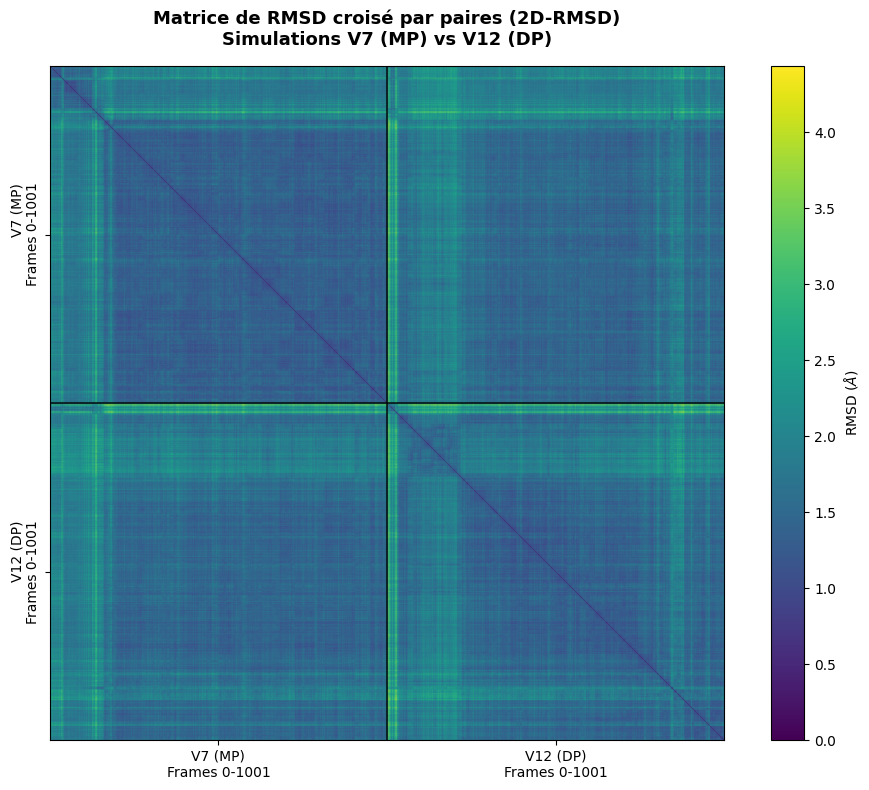

In [57]:
plt.figure(figsize=(10, 8))
plt.imshow(df_full, cmap='viridis', origin='upper')

plt.axvline(x=1001, color='black', linewidth=1.5, alpha=0.7)
plt.axhline(y=1001, color='black', linewidth=1.5, alpha=0.7)

tick_positions = [500, 1502]
tick_labels = ['V7 (MP)\nFrames 0-1001', 'V12 (DP)\nFrames 0-1001']

plt.xticks(tick_positions, tick_labels, fontsize=10)
plt.yticks(tick_positions, tick_labels, fontsize=10, rotation=90, va='center')

#plt.xlabel('Simulations comparées (Axe X)', fontsize=12, fontweight='bold', labelpad=10)
#plt.ylabel('Simulations comparées (Axe Y)', fontsize=12, fontweight='bold', labelpad=15)
plt.colorbar(label=r'RMSD ($\AA$)')

plt.title('Matrice de RMSD croisé par paires (2D-RMSD)\nSimulations V7 (MP) vs V12 (DP)', 
        fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/M1_STAGE/Manips/Figures/pw_rmsd_V7_V12.png", bbox_inches='tight', dpi=150)
plt.show()

# Make classification tree (Hclust)

In [76]:
#save all calculated matrices as csv files for later use
df1.to_csv("/content/drive/MyDrive/M1_STAGE/Manips/Tables/pw_rmsd_V7_V7.csv", index=False)
df2.to_csv("/content/drive/MyDrive/M1_STAGE/Manips/Tables/pw_rmsd_V7_V12.csv", index=False)
df3.to_csv("/content/drive/MyDrive/M1_STAGE/Manips/Tables/pw_rmsd_V12_V7.csv", index=False)
df4.to_csv("/content/drive/MyDrive/M1_STAGE/Manips/Tables/pw_rmsd_V12_V12.csv", index=False)
df_full.to_csv("/content/drive/MyDrive/M1_STAGE/Manips/Tables/pw_rmsd_full.csv", index=False)

In [58]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
import seaborn as sns

# convert your 2D 2002x2002 matrix into a condensed 1D vector
condensed_matrix = squareform(df_full, checks=False)

# Pass the condensed vector to linkage. 
# drop the metric="euclidean" argument because the distances are already calculated!
complete_clustering = linkage(condensed_matrix, method="ward")

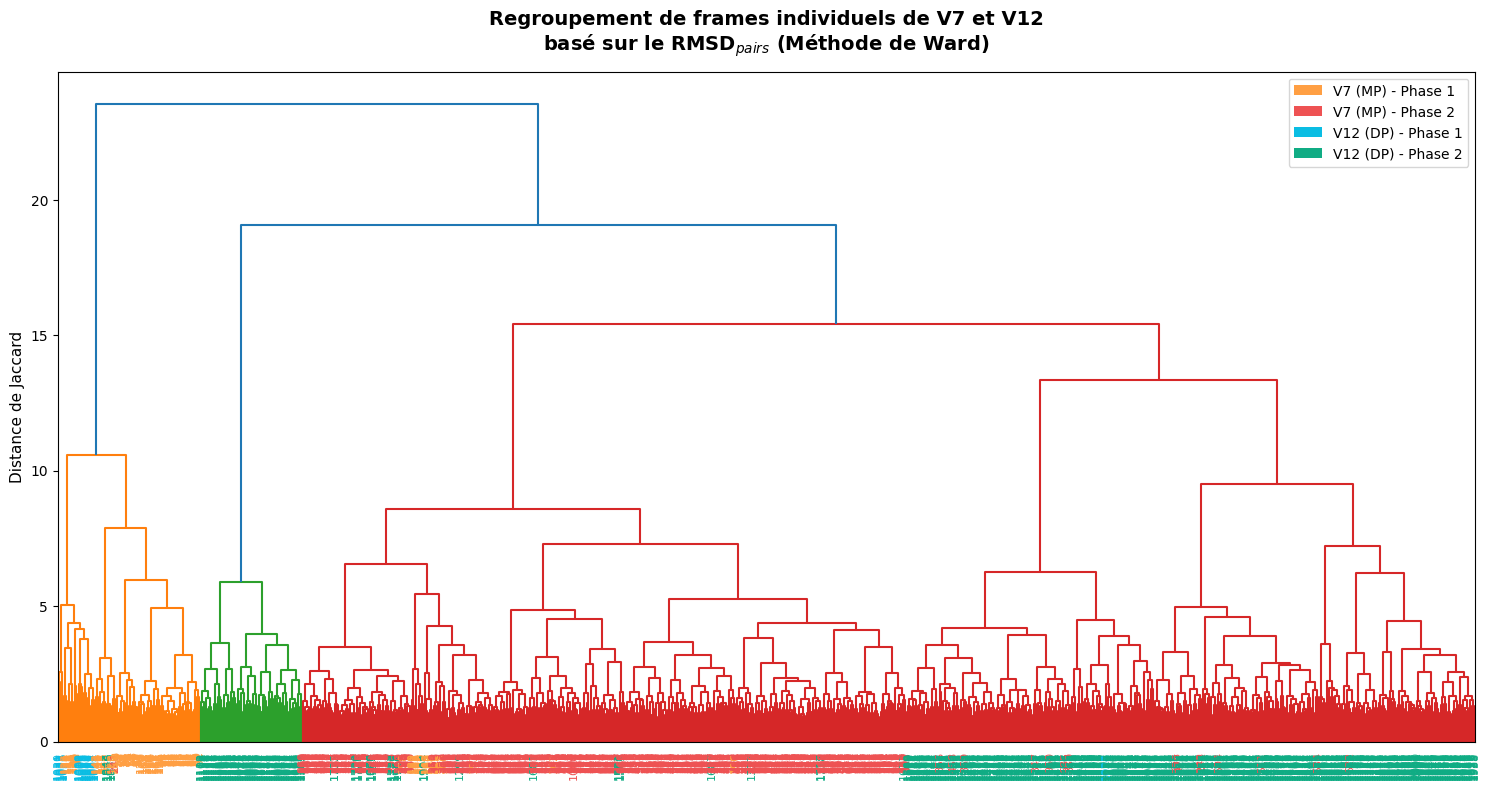

In [63]:
# 1. Define color palette
color_map = {
    'V7_Phase1':  '#FF9F43',  # Bright Orange
    'V7_Phase2':  '#EE5253',  # Crimson Red
    'V12_Phase1': '#0ABDE3',  # Cyan Blue
    'V12_Phase2': '#10AC84'   # Emerald Green
}

# 2. Plot the dendrogram
fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(complete_clustering, leaf_font_size=8, orientation='top')

plt.title("Regroupement de frames individuels de V7 et V12\nbasé sur le RMSD$_{pairs}$ (Méthode de Ward)",
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Distance de Jaccard", fontsize=11)

# 3. Dynamic leaf text color assignment loop
xlbls = ax.get_xmajorticklabels()

for lbl in xlbls:
    text = lbl.get_text()
    if text.isdigit():
        abs_idx = int(text) # This is the absolute index from 0 to 2001
        
        # Determine exactly which simulation and phase this leaf represents
        if abs_idx < 1001:
            sim = 'V7'
            phase = 'Phase1' if abs_idx <= 198 else 'Phase2'
        else:
            sim = 'V12'
            local_frame = abs_idx - 1001
            phase = 'Phase1' if local_frame <= 35 else 'Phase2'
            
        # Select the target color key
        state_key = f"{sim}_{phase}"
        lbl.set_color(color_map[state_key])
        
# 4. Add a visual legend to the plot so your report reader knows what the colors mean
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['V7_Phase1'], label='V7 (MP) - Phase 1'),
    Patch(facecolor=color_map['V7_Phase2'], label='V7 (MP) - Phase 2'),
    Patch(facecolor=color_map['V12_Phase1'], label='V12 (DP) - Phase 1'),
    Patch(facecolor=color_map['V12_Phase2'], label='V12 (DP) - Phase 2'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

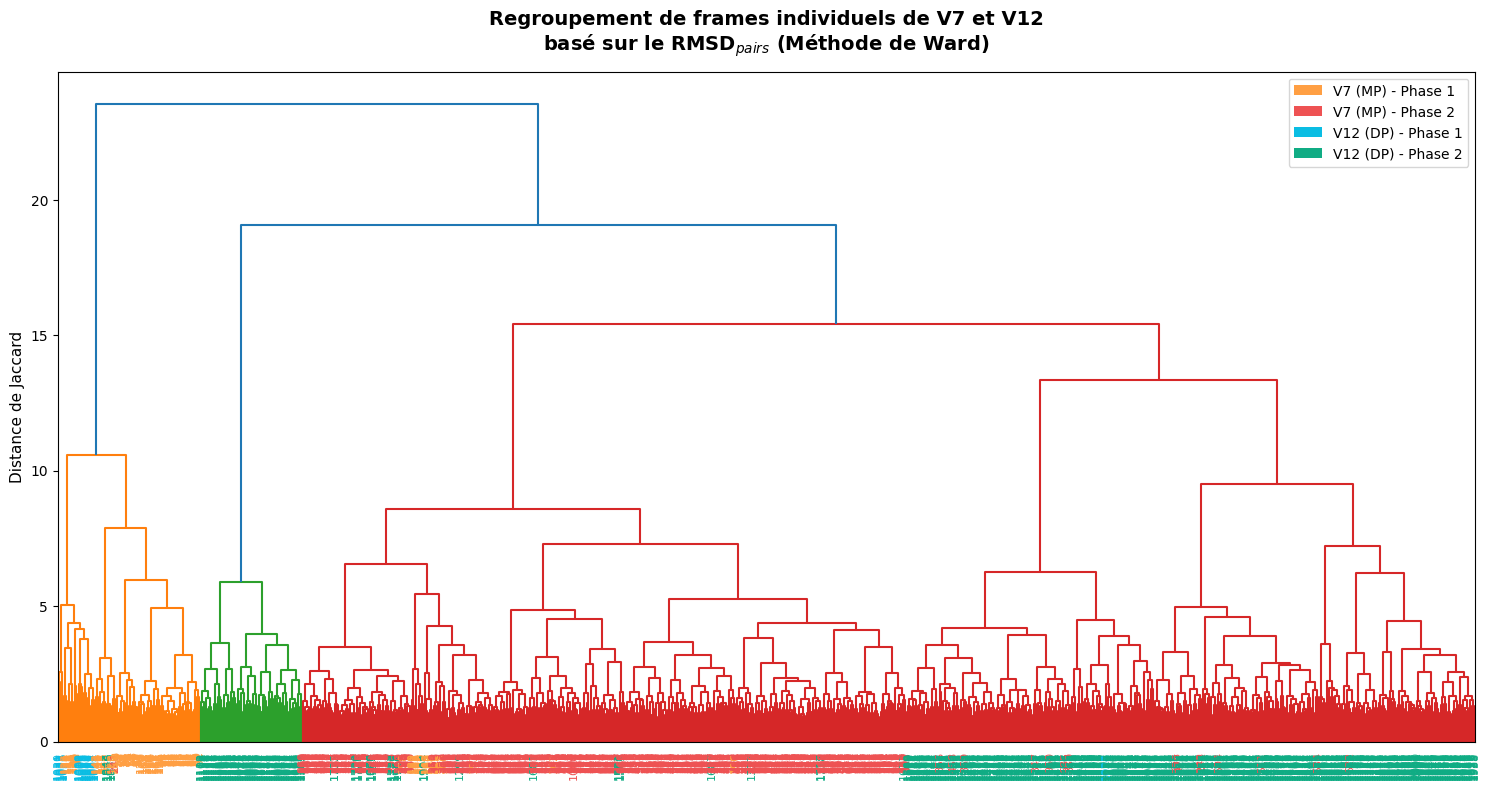

In [ ]:
# 2. Plot the dendrogram with clusters separation
fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(complete_clustering, leaf_font_size=8, orientation='top')

plt.title("Regroupement de frames individuels de V7 et V12\nbasé sur le RMSD$_{pairs}$ (Méthode de Ward)",
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Distance de Jaccard", fontsize=11)

# 3. Dynamic leaf text color assignment loop
xlbls = ax.get_xmajorticklabels()

for lbl in xlbls:
    text = lbl.get_text()
    if text.isdigit():
        abs_idx = int(text) # This is the absolute index from 0 to 2001
        
        # Determine exactly which simulation and phase this leaf represents
        if abs_idx < 1001:
            sim = 'V7'
            phase = 'Phase1' if abs_idx <= 198 else 'Phase2'
        else:
            sim = 'V12'
            local_frame = abs_idx - 1001
            phase = 'Phase1' if local_frame <= 35 else 'Phase2'
            
        # Select the target color key
        state_key = f"{sim}_{phase}"
        lbl.set_color(color_map[state_key])
        
# 4. Add a visual legend to the plot so your report reader knows what the colors mean
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['V7_Phase1'], label='V7 (MP) - Phase 1'),
    Patch(facecolor=color_map['V7_Phase2'], label='V7 (MP) - Phase 2'),
    Patch(facecolor=color_map['V12_Phase1'], label='V12 (DP) - Phase 1'),
    Patch(facecolor=color_map['V12_Phase2'], label='V12 (DP) - Phase 2'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True)
#cluster separation lines
from scipy.cluster.hierarchy import fcluster
cluster_labels = fcluster(complete_clustering, t=8, criterion='distance')
unique_clusters = np.unique(cluster_labels)
for cluster in unique_clusters:
    cluster_indices = np.where(cluster_labels == cluster)[0]
    if len(cluster_indices) > 0:
        last_index = cluster_indices[-1]
        plt.axhline(y=last_index, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

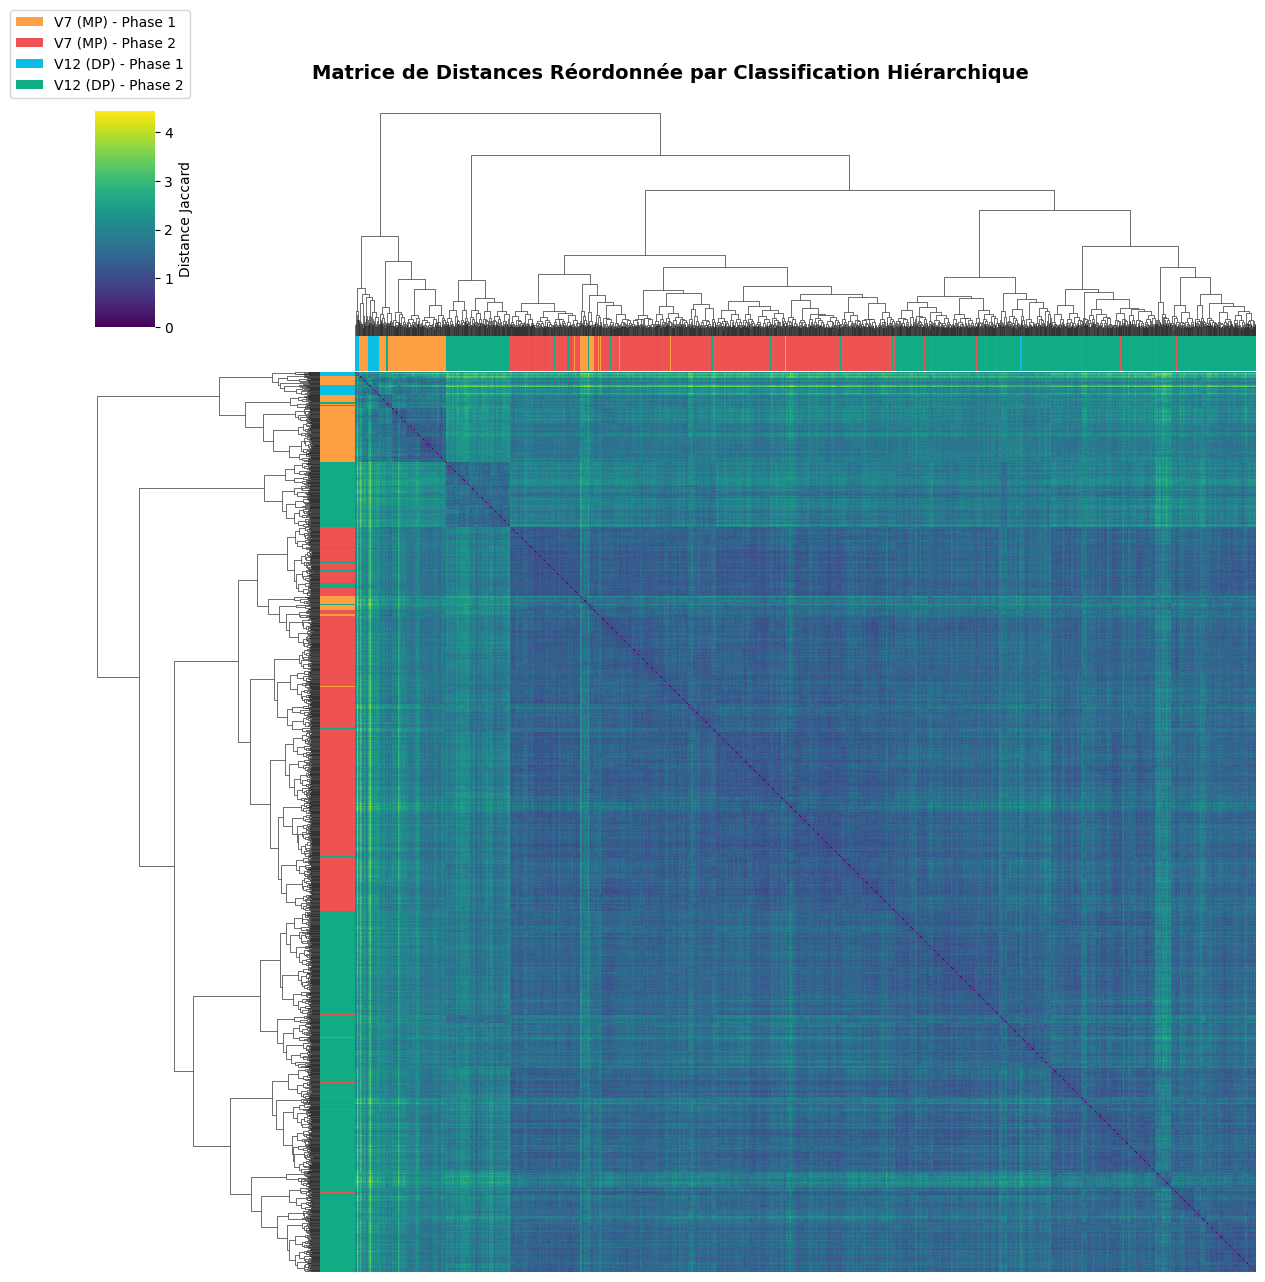

In [ ]:

# 1. Define your 4-state color map for the row/column sidebars
color_map = {
    'V7_Phase1':  '#FF9F43',  
    'V7_Phase2':  '#EE5253',  
    'V12_Phase1': '#0ABDE3',  
    'V12_Phase2': '#10AC84'   
}

# 2. Create a list of colors corresponding to every row/column in your 2002 dataset
# This adds a color bar between the tree and the heatmap to label phases explicitly!
meta_colors = []
for abs_idx in range(len(df_full)):
    if abs_idx < 1001:
        phase = 'Phase1' if abs_idx <= 198 else 'Phase2'
        meta_colors.append(color_map[f"V7_{phase}"])
    else:
        local_frame = abs_idx - 1001
        phase = 'Phase1' if local_frame <= 35 else 'Phase2'
        meta_colors.append(color_map[f"V12_{phase}"])

# 3. Plot the combined Clustermap
# We pass your pre-computed 'complete_clustering' linkage to both row and column links
g = sns.clustermap(
    df_full,
    row_linkage=complete_clustering,
    col_linkage=complete_clustering,
    cmap='viridis',
    row_colors=meta_colors,      # Displays structural phase color track on the left
    col_colors=meta_colors,      # Displays structural phase color track on the top
    figsize=(12, 12),
    xticklabels=False,           # Hide 2002 text labels to avoid overcrowding
    yticklabels=False,
    cbar_kws={'label': 'Distance Jaccard'}
)

# 4. Add titles and adjust the position of the layout elements
g.fig.suptitle("Matrice de Distances Réordonnée par Classification Hiérarchique", 
               fontsize=14, fontweight='bold', y=1.02)

# 5. Add a legend so your professor understands the side colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map['V7_Phase1'], label='V7 (MP) - Phase 1'),
    Patch(facecolor=color_map['V7_Phase2'], label='V7 (MP) - Phase 2'),
    Patch(facecolor=color_map['V12_Phase1'], label='V12 (DP) - Phase 1'),
    Patch(facecolor=color_map['V12_Phase2'], label='V12 (DP) - Phase 2'),
]
plt.gca().legend(handles=legend_elements, bbox_to_anchor=(1.7, 1.5), loc='upper right', frameon=True)

plt.show()

In [71]:
unique_clusters

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [31]:
# build a long-form dataframe from the square distance matrix
distance_matrix = df_full.drop(columns=['Cluster'], errors='ignore')

n_frames = len(V7.trajectory)
frame_cluster = cut_tree(complete_clustering, n_clusters=4).reshape(-1)

rmsd_df = (
    distance_matrix
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Frame_i', 'level_1': 'Frame_j', 0: 'RMSD'})
)

In [32]:
rmsd_df['Frame_i'] = rmsd_df['Frame_i'].astype(int)
rmsd_df['Frame_j'] = rmsd_df['Frame_j'].astype(int)
rmsd_df['Cluster_i'] = frame_cluster[rmsd_df['Frame_i']]
rmsd_df['Cluster_j'] = frame_cluster[rmsd_df['Frame_j']]

In [33]:
# 1. Take a shallow copy so we don't accidentally ruin your original df_full
matrix_fixed = df_full.drop(columns=['Cluster'], errors='ignore').copy()

# 2. FORCE the rows and columns to have sequential, unique numbers from 0 to 2001
# This completely bypasses the duplicate 0-1000 names!
absolute_indices = np.arange(len(matrix_fixed))
matrix_fixed.index = absolute_indices
matrix_fixed.columns = absolute_indices

# 3. Stack the matrix now. Because the indices are unique, the data won't overwrite!
rmsd_df = matrix_fixed.stack().reset_index()
rmsd_df.columns = ['index_i', 'index_j', 'RMSD']

# 4. Now, safely determine the true Simulation names based on these clear absolute boundaries
rmsd_df['Sim_i'] = np.where(rmsd_df['index_i'] < 1001, 'V7', 'V12')
rmsd_df['Sim_j'] = np.where(rmsd_df['index_j'] < 1001, 'V7', 'V12')
rmsd_df['Sim/Sim'] = rmsd_df['Sim_i'] + '/' + rmsd_df['Sim_j']

# 5. Bring back your clean 0-1000 local frame numbers
rmsd_df['Frame_i'] = np.where(rmsd_df['Sim_i'] == 'V7', rmsd_df['index_i'], rmsd_df['index_i'] - 1001)
rmsd_df['Frame_j'] = np.where(rmsd_df['Sim_j'] == 'V7', rmsd_df['index_j'], rmsd_df['index_j'] - 1001)

# 6. Bind your hclust tree assignments
rmsd_df['Cluster_i'] = frame_cluster[rmsd_df['index_i']]
rmsd_df['Cluster_j'] = frame_cluster[rmsd_df['index_j']]

In [34]:
rmsd_df[rmsd_df['Sim/Sim'] == 'V7/V12'].head()

,index_i,index_j,RMSD,Sim_i,Sim_j,Sim/Sim,Frame_i,Frame_j,Cluster_i,Cluster_j
1001,0,1001,1.753106,V7,V12,V7/V12,0,0,0,1
1002,0,1002,1.442317,V7,V12,V7/V12,0,1,0,1
1003,0,1003,1.585706,V7,V12,V7/V12,0,2,0,1
1004,0,1004,1.683667,V7,V12,V7/V12,0,3,0,1
1005,0,1005,2.809990,V7,V12,V7/V12,0,4,0,2


/tmp/ipykernel_5032/2097976416.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_i', y='RMSD', data=rmsd_df, showfliers=False, palette='Set2')


<Axes: xlabel='Cluster_i', ylabel='RMSD'>

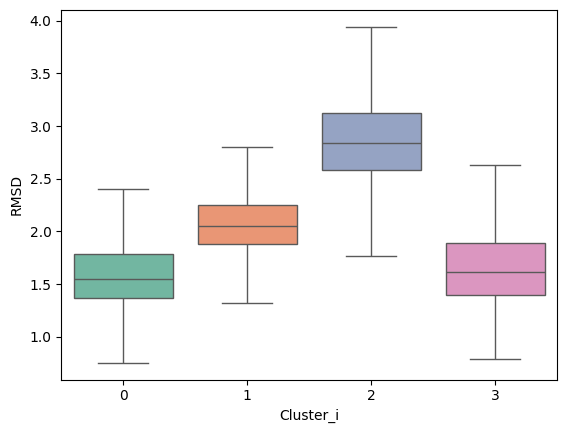

In [35]:
sns.boxplot(x='Cluster_i', y='RMSD', data=rmsd_df, showfliers=False, palette='Set2')


# Supervised classifier (Decision Tree)

In [36]:
X = matrix_fixed.values
# Create target list for the 2002 rows
labels = []
for abs_idx in range(2002):
    if abs_idx < 1001:  # It's a V7 frame
        phase = "Phase 1" if abs_idx <= 198 else "Phase 2"
    else:               # It's a V12 frame
        local_frame = abs_idx - 1001
        phase = "Phase 1" if local_frame <= 35 else "Phase 2"
    labels.append(phase)

y = np.array(labels)

In [39]:
# Pass your 1D array of labels 'y' to stratify
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
print("Training set label counts:\n", pd.Series(y_train).value_counts())
print("Testing set label counts:\n", pd.Series(y_test).value_counts())

Training set label counts:
 Phase 2    1413
Phase 1     188
Name: count, dtype: int64
Testing set label counts:
 Phase 2    354
Phase 1     47
Name: count, dtype: int64


In [45]:
import pydotplus
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

--- Evaluation on Test Set ---
              precision    recall  f1-score   support

     Phase 1       0.93      0.91      0.92        47
     Phase 2       0.99      0.99      0.99       354

    accuracy                           0.98       401
   macro avg       0.96      0.95      0.96       401
weighted avg       0.98      0.98      0.98       401



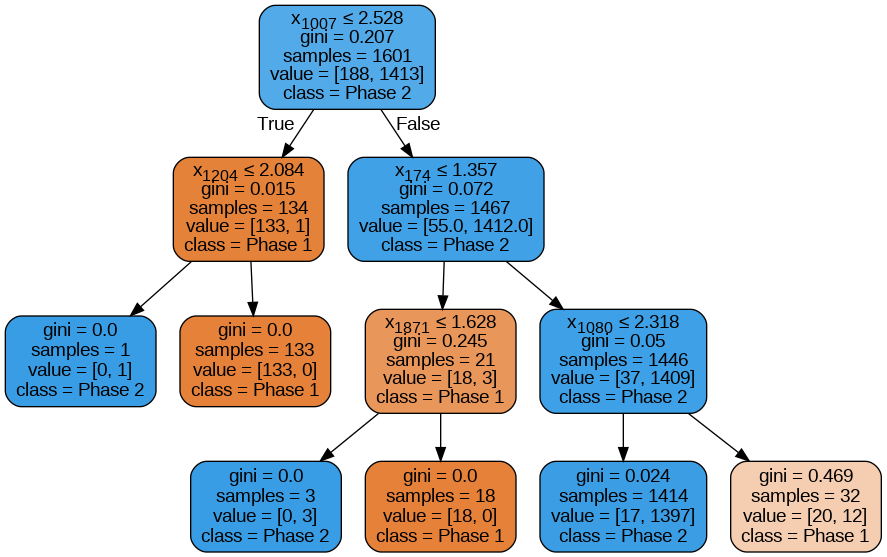

In [47]:
# 1. Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

# 2. Define your classifier and train it ONLY on the training split
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train) # <--- Pass the split here!

# 3. Test your model's real predictive power using the test set
y_pred = clf.predict(X_test)

# 4. Show the classification metrics
from sklearn.metrics import classification_report, confusion_matrix
print("--- Evaluation on Test Set ---")
print(classification_report(y_test, y_pred))

# 5. Generate the new visual tree based only on the training split
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                class_names=clf.classes_, # This will label leaves as "Phase 1" or "Phase 2"
                special_characters=True,proportion=False)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))

Image(graph.create_png())


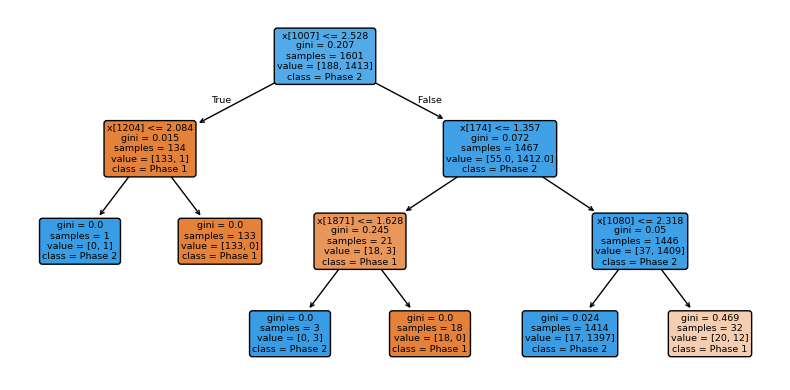

In [51]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from io import StringIO

fig, ax = plt.subplots(figsize=(8, 4))
plot_tree(clf,
          class_names=clf.classes_,
          filled=True, 
          rounded=True,
          proportion=False,
          ax=ax)

#ax.set_title('Decision Tree – discriminating bonds between sim-phases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Stratified K-Fold Cross-Validation
from statistics import mean, stdev
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold
from sklearn import linear_model
from sklearn import datasets

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
lst_accu_stratified = []

for train_index, test_index in skf.split(X, y):
	X_train_fold, X_test_fold = X[train_index], X[test_index]
	y_train_fold, y_test_fold = y[train_index], y[test_index]
	clf.fit(X_train_fold, y_train_fold)
	lst_accu_stratified.append(clf.score(X_test_fold, y_test_fold))

In [ ]:
print('List of possible accuracy:', lst_accu_stratified)
print('\nMaximum Accuracy That can be obtained from this model is:',
	max(lst_accu_stratified)*100, '%')
print('\nMinimum Accuracy:',
	min(lst_accu_stratified)*100, '%')
print('\nOverall Accuracy:',
	mean(lst_accu_stratified)*100, '%')
print('\nStandard Deviation is:', stdev(lst_accu_stratified))

List of possible accuracy: [0.9800995024875622, 0.9651741293532339, 0.975, 0.965, 0.975, 0.98, 0.98, 0.975, 0.98, 0.995]

Maximum Accuracy That can be obtained from this model is: 99.5 %

Minimum Accuracy: 96.5 %

Overall Accuracy: 97.70273631840796 %

Standard Deviation is: 0.008540430933611017
